<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/Part3_1_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3, Notebook 9, Autoencoder

We train an autoencoder on Block 1 images. The encoder will be reused in the next excersie

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/AppliedDL/face_age.zip" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/AppliedDL/data_splits" /content/
!unzip -q /content/face_age.zip -d /content/

## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
    print(f"mem {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

cuda
NVIDIA A100-SXM4-40GB
mem 42.4 GB


## 4. Inspect Blocks split

Quick check that block1.csv is where we expect and has the columns the dataset class will use later.

In [6]:
b1 = pd.read_csv("/content/data_splits/block1.csv")
print(f"block1 size {len(b1)}")
print(b1.columns.tolist())
b1.head()

b2 = pd.read_csv("/content/data_splits/block2.csv")
print(f"block2 size {len(b2)}")
print(b1.columns.tolist())
b2.head()

block1 size 4392
['path', 'age', 'fname', 'age_category']
block2 size 4392
['path', 'age', 'fname', 'age_category']


,path,age,fname,age_category
0,face_age/028/3218.png,28,3218.png,youth
1,face_age/047/7764.png,47,7764.png,mature
2,face_age/010/8615.png,10,8615.png,child
3,face_age/039/7494.png,39,7494.png,mid
4,face_age/054/9115.png,54,9115.png,mature


## 5. Architecture

Encoder, three ResBlock units, channels 3 → 32 → 64 → 128, spatial 200 → 100 → 50 → 25. Decoder, three ResBlockUp units that reverse the shape, channels 128 → 64 → 32 → 32, spatial 25 → 50 → 100 → 200. Final conv maps 32 → 3 with no activation.

In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        identity = self.proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        out = self.pool(out)
        return out

In [9]:
# mirror of ResBlock, ConvTranspose2d swapped in for maxpool to grow spatial instead of shrink
class ResBlockUp(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size):
        super().__init__()
        pad = kernel_size // 2
        self.up = nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.up(x)
        identity = self.proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out

In [11]:
class AutoEncoder(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        # encoder, mirror of BestModel features from notebook 8
        self.encoder = nn.Sequential(
            ResBlock(3, 32, kernel_size),
            ResBlock(32, 64, kernel_size),
            ResBlock(64, 128, kernel_size),
        )
        # decoder grows the encoder output back to image size
        self.decoder = nn.Sequential(
            ResBlockUp(128, 64, kernel_size),
            ResBlockUp(64, 32, kernel_size),
            ResBlockUp(32, 32, kernel_size),
            nn.Conv2d(32, 3, kernel_size, padding=kernel_size // 2),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


# shape check before training, easier to debug here than mid epoch
m = AutoEncoder(kernel_size=3).to(device)
n_params = sum(p.numel() for p in m.parameters())
print(f"params {n_params:,}")

x = torch.randn(2, 3, 200, 200).to(device)
z = m.encoder(x)
out = m(x)
print(f"input  {tuple(x.shape)}")
print(f"latent {tuple(z.shape)}")
print(f"output {tuple(out.shape)}")

params 553,347
input  (2, 3, 200, 200)
latent (2, 128, 25, 25)
output (2, 3, 200, 200)


## 6. Data

Block 1 split 90/10 for autoencoder train and val. No augmentation, target is the input image so they must match.

In [12]:
# split block1 into 90/10 for the autoencoder, save to /content so the loader can read like the other splits
b1 = pd.read_csv("/content/data_splits/block1.csv")
b1 = b1.sample(frac=1, random_state=42).reset_index(drop=True)
n_val = int(len(b1) * 0.1)
b1.iloc[n_val:].to_csv("/content/ae_train.csv", index=False)
b1.iloc[:n_val].to_csv("/content/ae_val.csv", index=False)
print(f"ae train {len(b1) - n_val}  ae val {n_val}")

ae train 3953  ae val 439


In [13]:
class FaceImageDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"/content/{row['path']}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, img  # for autoencoder, target is the input itself

In [14]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# no augmentation, input and target must match
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [15]:
train_ds = FaceImageDataset("/content/ae_train.csv", transform=tf)
val_ds = FaceImageDataset("/content/ae_val.csv", transform=tf)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"train batches {len(train_loader)}  val batches {len(val_loader)}")
imgs, targets = next(iter(train_loader))
print(f"batch shape {tuple(imgs.shape)}  target shape {tuple(targets.shape)}")
print(f"pixel range after normalize  min {imgs.min():.2f}  max {imgs.max():.2f}")

train batches 62  val batches 7
batch shape (64, 3, 200, 200)  target shape (64, 3, 200, 200)
pixel range after normalize  min -2.12  max 2.64


## 7. Train and eval functions

Same skeleton as notebook 8 in part 2

In [16]:
def train_one_epoch(model, loader, loss_fn, optimizer, scheduler=None):
    model.train()
    total = 0
    n = 0
    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = loss_fn(out, targets)
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
        n += imgs.size(0)
    if scheduler is not None:
        scheduler.step()
    return total / n


def evaluate(model, loader, loss_fn):
    model.eval()
    total = 0
    n = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            out = model(imgs)
            loss = loss_fn(out, targets)
            total += loss.item() * imgs.size(0)
            n += imgs.size(0)
    return total / n

## 8. Train

AdamW, cosine LR 1e-3 to 1e-5, MSE loss. Track best by val loss, early stop on patience.

In [17]:
model = AutoEncoder(kernel_size=3).to(device)

# 30 epochs with patience 8 to investigate further than in last excersie
max_epochs = 30
patience = 8

loss_fn = nn.MSELoss()

# AdamW + cosine LR, same as notebook 8
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-5)

best_val = float("inf")
best_state = None
hist = {"train": [], "val": [], "lr": []}
no_improve = 0

t0 = time.time()
for epoch in range(max_epochs):
    tr = train_one_epoch(model, train_loader, loss_fn, opt, sched)
    vl = evaluate(model, val_loader, loss_fn)
    hist["train"].append(tr)
    hist["val"].append(vl)
    hist["lr"].append(opt.param_groups[0]["lr"])
    print(f"epoch {epoch+1:2d}  train {tr:.4f}  val {vl:.4f}  lr {opt.param_groups[0]['lr']:.2e}")

    if vl < best_val:
        best_val = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"early stop at epoch {epoch+1}")
            break

print(f"best val {best_val:.4f}  time {time.time() - t0:.1f}s")

epoch  1  train 0.1961  val 0.0554  lr 9.97e-04
epoch  2  train 0.0478  val 0.0560  lr 9.89e-04
epoch  3  train 0.0379  val 0.0315  lr 9.76e-04
epoch  4  train 0.0355  val 0.0356  lr 9.57e-04
epoch  5  train 0.0351  val 0.0287  lr 9.34e-04
epoch  6  train 0.0313  val 0.0282  lr 9.05e-04
epoch  7  train 0.0303  val 0.0247  lr 8.73e-04
epoch  8  train 0.0313  val 0.0284  lr 8.36e-04
epoch  9  train 0.0264  val 0.0231  lr 7.96e-04
epoch 10  train 0.0240  val 0.0163  lr 7.53e-04
epoch 11  train 0.0229  val 0.0189  lr 7.06e-04
epoch 12  train 0.0217  val 0.0163  lr 6.58e-04
epoch 13  train 0.0228  val 0.0140  lr 6.08e-04
epoch 14  train 0.0176  val 0.0188  lr 5.57e-04
epoch 15  train 0.0167  val 0.0165  lr 5.05e-04
epoch 16  train 0.0160  val 0.0164  lr 4.53e-04
epoch 17  train 0.0147  val 0.0162  lr 4.02e-04
epoch 18  train 0.0176  val 0.0231  lr 3.52e-04
epoch 19  train 0.0142  val 0.0120  lr 3.04e-04
epoch 20  train 0.0147  val 0.0107  lr 2.58e-04
epoch 21  train 0.0146  val 0.0114  lr 2

## 9. Loss curves

Train and val MSE across epochs, plus the cosine LR schedule.

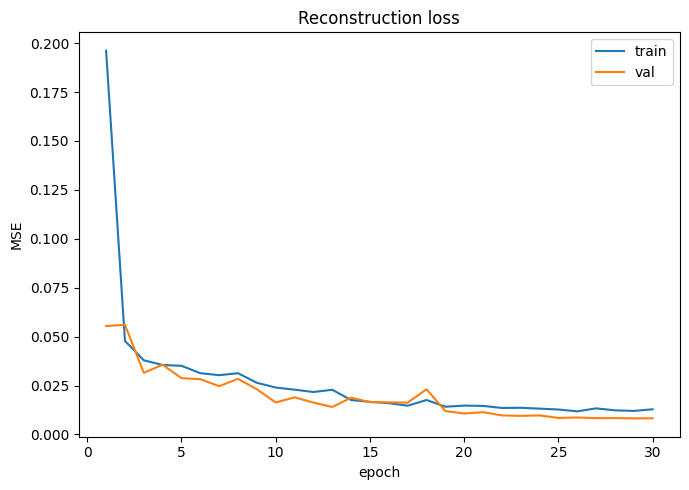

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
epochs = range(1, len(hist["train"]) + 1)
ax.plot(epochs, hist["train"], label="train")
ax.plot(epochs, hist["val"], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.set_title("Reconstruction loss")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Reconstructions

Val images vs reconstructions side by side. Visual sanity check of what the encoder actually learned.

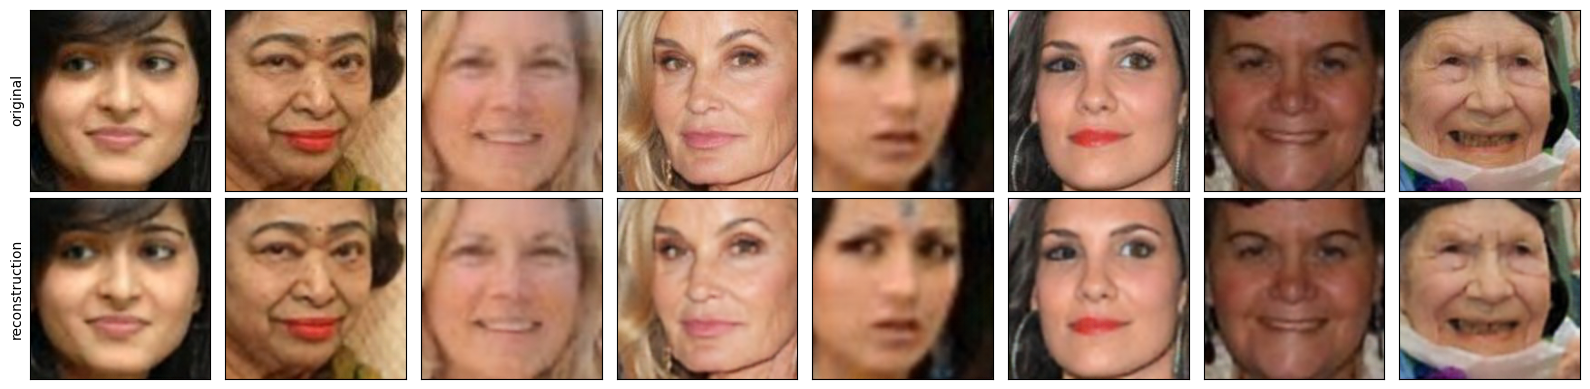

In [22]:
# load best weights from training, the last epoch was not necessarily the best
model.load_state_dict(best_state)
model.eval()

n_show = 8
imgs, _ = next(iter(val_loader))
imgs = imgs[:n_show].to(device)
with torch.no_grad():
    recon = model(imgs)

# undo ImageNet normalisation for display, clamp into 0 to 1 in case the output went slightly out of range
mean = torch.tensor(imagenet_mean).view(1, 3, 1, 1).to(device)
std = torch.tensor(imagenet_std).view(1, 3, 1, 1).to(device)
orig = (imgs * std + mean).clamp(0, 1).cpu()
recon = (recon * std + mean).clamp(0, 1).cpu()

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    axes[0, i].imshow(orig[i].permute(1, 2, 0))
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstruction")
plt.tight_layout()
plt.show()

## 11. Save Model

In [23]:
import os
os.makedirs("/content/models", exist_ok=True)

torch.save({
    "full_state": model.state_dict(),
    "encoder_state": model.encoder.state_dict(),
    "arch": "resblock_x3_ch3_32_64_128",
    "kernel_size": 3,
    "val_mse": best_val,
    "history": hist,
}, "/content/models/ae_block1.pt")

!cp /content/models/ae_block1.pt "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"
print("saved")

saved
